In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from google.colab import files
import kagglehub

In [18]:
import os
dataset_path = "/kaggle/input/bitcoin-historical-data"
file_path = os.path.join(dataset_path, 'btcusd_1-min_data.csv')
dataset = pd.read_csv(file_path)

In [4]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime


In [5]:
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

In [20]:
dataset

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
...,...,...,...,...,...,...
7492000,1.775002e+09,68109.00,68109.00,68057.00,68098.00,0.821987
7492001,1.775002e+09,68099.00,68117.00,68081.00,68117.00,0.938345
7492002,1.775002e+09,68127.00,68167.00,68127.00,68129.00,0.459205
7492003,1.775002e+09,68129.00,68140.00,68120.00,68120.00,0.343214


In [22]:
df = dataset.copy()

In [23]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

In [24]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format = ('y%-m%-d%'))

In [25]:
df

,Timestamp,Open,High,Low,Close,Volume
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.000000
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.000000
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.000000
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.000000
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.000000
...,...,...,...,...,...,...
7492000,2026-04-01 00:01:00,68109.00,68109.00,68057.00,68098.00,0.821987
7492001,2026-04-01 00:02:00,68099.00,68117.00,68081.00,68117.00,0.938345
7492002,2026-04-01 00:03:00,68127.00,68167.00,68127.00,68129.00,0.459205
7492003,2026-04-01 00:04:00,68129.00,68140.00,68120.00,68120.00,0.343214


In [26]:
df['year'] = df['Timestamp'].dt.year
df['month'] = df['Timestamp'].dt.month
df['day'] = df['Timestamp'].dt.day
df['hour'] = df['Timestamp'].dt.hour
df['minute'] = df['Timestamp'].dt.minute

In [27]:
df_date = df.columns[0]
df = df.set_index(df_date)

In [28]:
day = df['day']
month = df['month']
year = df['year']
hour = df['hour']
minute = df['minute']

In [32]:
df

,Open,High,Low,Close,Volume,year,month,day,hour,minute
Timestamp,,,,,,,,,,
2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,1
2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,2
2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,3
2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,4
2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,5
...,...,...,...,...,...,...,...,...,...,...
2026-04-01 00:01:00,68109.00,68109.00,68057.00,68098.00,0.821987,2026,4,1,0,1
2026-04-01 00:02:00,68099.00,68117.00,68081.00,68117.00,0.938345,2026,4,1,0,2
2026-04-01 00:03:00,68127.00,68167.00,68127.00,68129.00,0.459205,2026,4,1,0,3


In [31]:
df_date

'Timestamp'

In [34]:
date = df[(year >= 2024) & (year <= 2025) & (day >= 1) & (month >= 1) & (hour == 0) & (minute == 0)]

In [37]:
columns = ['hour', 'minute' ]
date = date.drop(columns = columns, axis = 1)

In [38]:
df = df.drop_duplicates()

In [39]:
date

,Open,High,Low,Close,Volume,year,month,day
Timestamp,,,,,,,,
2024-01-01,42652.0,42655.0,42651.0,42651.0,0.014804,2024,1,1
2024-01-02,43147.0,43147.0,43147.0,43147.0,0.013160,2024,1,2
2024-01-03,45185.0,45213.0,45162.0,45197.0,1.009502,2024,1,3
2024-01-04,42284.0,42389.0,42284.0,42332.0,4.136539,2024,1,4
2024-01-05,44095.0,44129.0,44095.0,44128.0,0.757281,2024,1,5
...,...,...,...,...,...,...,...,...
2025-12-27,87296.0,87315.0,87296.0,87311.0,2.748943,2025,12,27
2025-12-28,87802.0,87871.0,87802.0,87845.0,0.914658,2025,12,28
2025-12-29,87871.0,87881.0,87835.0,87835.0,3.040755,2025,12,29


In [40]:
result_yanuar_week = seasonal_decompose(date['Open'], model = 'additive', period = 365)
trend_yanuar_week = result_yanuar_week.trend
seasonal_yanuar_week = result_yanuar_week.seasonal
reisid_yanuar_week = result_yanuar_week.resid
observed_yanuar_week = result_yanuar_week.observed

<Figure size 1200x900 with 0 Axes>

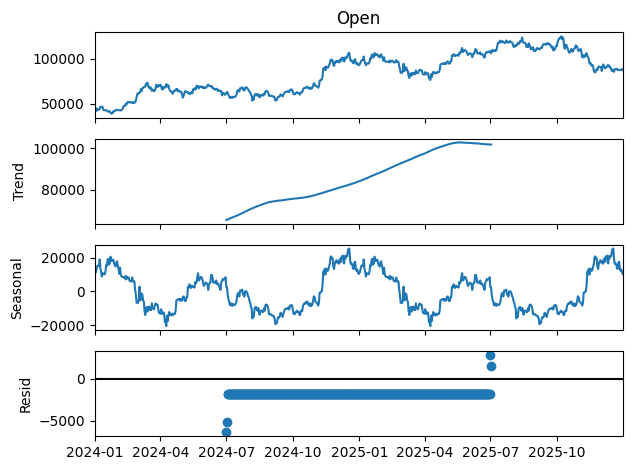

In [41]:
plt.figure(figsize = (12, 9))
result_yanuar_week.plot()
plt.show()

In [42]:
def adfuller_test(dataset, features):
    dataset = dataset.copy()
    for feature in features:

        name_feature = dataset[feature].name
        result = adfuller(dataset[feature])
        print(f'Произведен тест Дики Фуллера фичи : {name_feature}')
        print('Результаты:\n')
        if result[1] > 0.05:
            print('Ряд не Стационарен, необходимо дифференцирование')
            print('\nДифференцирование...')
            dataset[feature] = dataset[feature].diff()
            dataset = dataset.dropna()
            result2 = adfuller(dataset[feature])
            print('Результат после дифференцирования')
            if result2[1] > 0.05:
                print('Ряд не стационарен')
                print(f'ADF статистика {result2[0]}')
                print(f'p-value = {result2[1]}')
                print('Нужно брать разность d == 2\n')
            else:
                print('Ряд стационарен')
                print(f'ADF статистика {result2[0]}')
                print(f'p-value = {result2[1]}')
                print('Нужно брать разность d == 1\n')

        else:
            print('Ряд стационарен. дифференцирование не нужно d == 0')
        print(f'ADF статистика {result[0]}')
        print(f'p-value = {result[1]}')
        print('Critical values:')
        for key, value in result[4].items():
            print('\t%s : %.3f\n'% (key, value))

In [43]:
columns_test_adfuller = ['Open', 'High', 'Low', 'Close', 'Volume']

In [44]:
adfuller_test(date, columns_test_adfuller)

Произведен тест Дики Фуллера фичи : Open
Результаты:

Ряд не Стационарен, необходимо дифференцирование

Дифференцирование...
Результат после дифференцирования
Ряд стационарен
ADF статистика -28.10578886793014
p-value = 0.0
Нужно брать разность d == 1

ADF статистика -1.8961409762262784
p-value = 0.33387868945648663
Critical values:
	1% : -3.439

	5% : -2.866

	10% : -2.569

Произведен тест Дики Фуллера фичи : High
Результаты:

Ряд не Стационарен, необходимо дифференцирование

Дифференцирование...
Результат после дифференцирования
Ряд стационарен
ADF статистика -28.12589664134545
p-value = 0.0
Нужно брать разность d == 1

ADF статистика -1.8852177787292839
p-value = 0.33904676726726946
Critical values:
	1% : -3.439

	5% : -2.866

	10% : -2.569

Произведен тест Дики Фуллера фичи : Low
Результаты:

Ряд не Стационарен, необходимо дифференцирование

Дифференцирование...
Результат после дифференцирования
Ряд стационарен
ADF статистика -28.099865828107784
p-value = 0.0
Нужно брать разность d 

In [45]:
day = date['day']
month = date['month']
year = date['year']

In [46]:
date_new = date[(year == 2025) & (month <= 4)]

In [47]:
def minmax_scal(dataset):
    dataset = dataset.copy()
    minmax = MinMaxScaler()
    for col in dataset.columns:
        dataset[col] = minmax.fit_transform(dataset[[col]])

    return dataset

In [51]:
x_scal = minmax_scal(x)


In [69]:
x = date_new.drop(columns = 'Open')
y = date_new['Open'].shift(-1)

In [70]:
y.shape

(120,)

In [56]:
date_new

,Open,High,Low,Close,Volume,year,month,day
Timestamp,,,,,,,,
2025-01-01,93347.0,93395.0,93347.0,93395.0,0.016150,2025,1,1
2025-01-02,94380.0,94408.0,94380.0,94408.0,0.476729,2025,1,2
2025-01-03,96895.0,96895.0,96895.0,96895.0,0.326052,2025,1,3
2025-01-04,98133.0,98240.0,98133.0,98223.0,0.422646,2025,1,4
2025-01-05,98218.0,98251.0,98218.0,98251.0,0.215887,2025,1,5
...,...,...,...,...,...,...,...,...
2025-04-26,94720.0,94725.0,94699.0,94713.0,0.181928,2025,4,26
2025-04-27,94662.0,94715.0,94662.0,94714.0,0.081242,2025,4,27
2025-04-28,93780.0,93827.0,93779.0,93783.0,0.203160,2025,4,28


In [75]:
col = 'Open'

In [76]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
y_scal = minmax.fit_transform(date_new[[col]])

In [77]:
x_train, x_test = x_scal[:96], x_scal[96:]
y_train, y_test = y_scal[:96], y_scal[96:]

In [78]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(96, 7)
(24, 7)
(96, 1)
(24, 1)


In [93]:
def keras_LSTM(x_tr,y_tr, x_tt ):


    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1

    )
    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.LSTM(64),
        keras.layers.Dense(64,activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model.fit(x_tr, y_tr, epochs = 100, batch_size = 32,
        verbose = 0, callbacks = [stopping_])

    predict= model.predict(x_tt, verbose = 0)

    return model, history ,predict

model_keras_LSTM, history_LSTM ,predict_keras = keras_LSTM(x_train, y_train, x_test)

Restoring model weights from the end of the best epoch: 100.


In [87]:
def convert_predict_to_df(predict, date_index_actual_data):

    pred_df = pd.DataFrame({
        'target' : [i[0] for i in predict]
    })
    pred_df = pred_df.set_index(date_index_actual_data)
    return pred_df

In [118]:
def visual_actual_or_prediction(actual, predict, name_model='', layers=''):
    plt.figure(figsize=(18, 8))

    if isinstance(actual, (pd.DataFrame, pd.Series)):
        actual_values = actual.values.flatten()
    else:
        actual_values = np.array(actual).flatten()

    if isinstance(predict, (pd.DataFrame, pd.Series)):
        predict_values = predict.values.flatten()
    else:
        predict_values = np.array(predict).flatten()

    actual_index = range(len(actual_values))
    predict_index = range(len(actual_values), len(actual_values) + len(predict_values))

    plt.plot(actual_index, actual_values, 'b-', label='Истинные данные', linewidth=2)
    plt.plot(predict_index, predict_values, 'r--', label='Предсказания модели', linewidth=2, marker='o', markersize=4)
    plt.axvline(x=len(actual_values), color='green', linestyle='--', alpha=0.5, label='Начало предсказаний')
    plt.title(f'Актуальные данные и данные предикта модели {name_model}, {layers} layers')
    plt.xlabel('Временные шаги')
    plt.ylabel('Нормализованная цена')
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")
    plt.show()

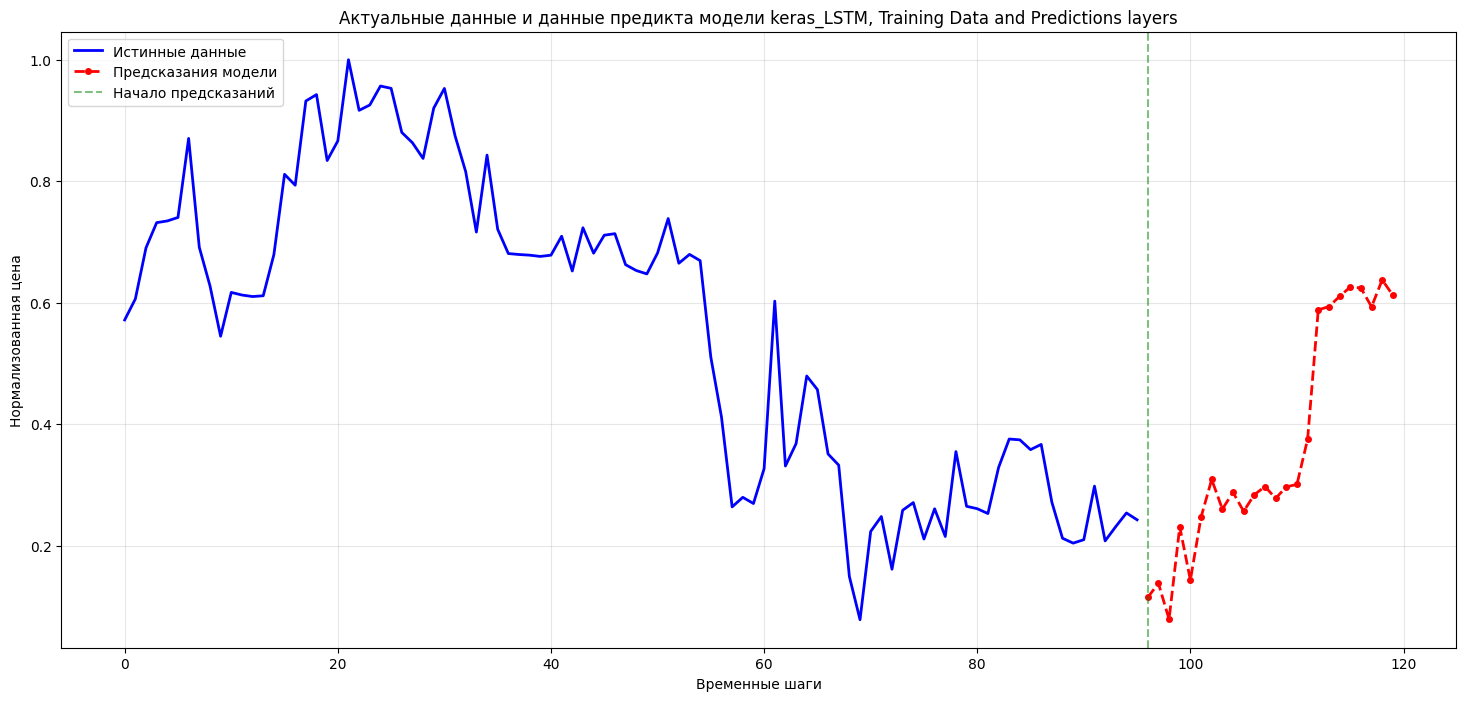

In [124]:
predict_model = convert_predict_to_df(predict_keras, x_test.index)
visual_actual_or_prediction(y_train, predict_model, 'keras_LSTM', 'Training Data and Predictions')

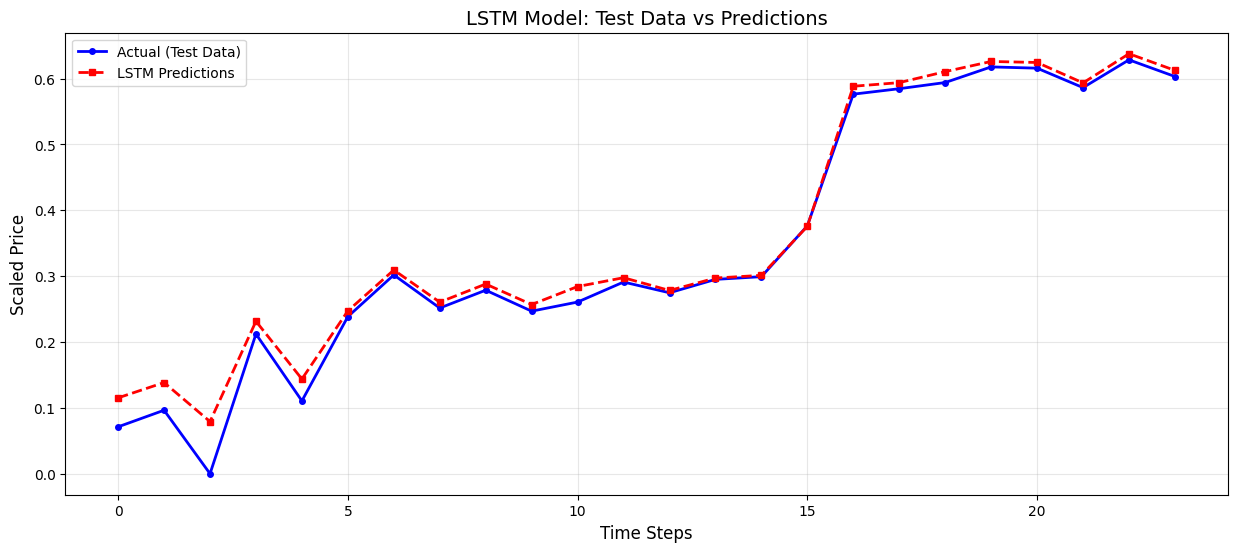

In [125]:
if 'y_test' in locals():
    plt.figure(figsize=(15, 6))
    x_axis = range(len(y_test))
    plt.plot(x_axis, y_test, 'b-', label='Actual (Test Data)', linewidth=2, marker='o', markersize=4)
    plt.plot(x_axis, predict_keras, 'r--', label='LSTM Predictions', linewidth=2, marker='s', markersize=4)
    plt.title('LSTM Model: Test Data vs Predictions', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Scaled Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [103]:
def keras_GRU(x_tr, y_tr, x_tt):

    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode='auto',
        restore_best_weights=True,
        verbose=1
    )

    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu', kernel_regularizer='l2'),
        keras.layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    history = model.fit(x_tr, y_tr, epochs=100, batch_size=32,
                        verbose=0, callbacks=[stopping_])

    predict = model.predict(x_tt, verbose=0)

    return model, history, predict


In [104]:
model_keras_GRU, history_GRU, predict_keras_GRU = keras_GRU(x_train, y_train, x_test)

Epoch 92: early stopping
Restoring model weights from the end of the best epoch: 82.


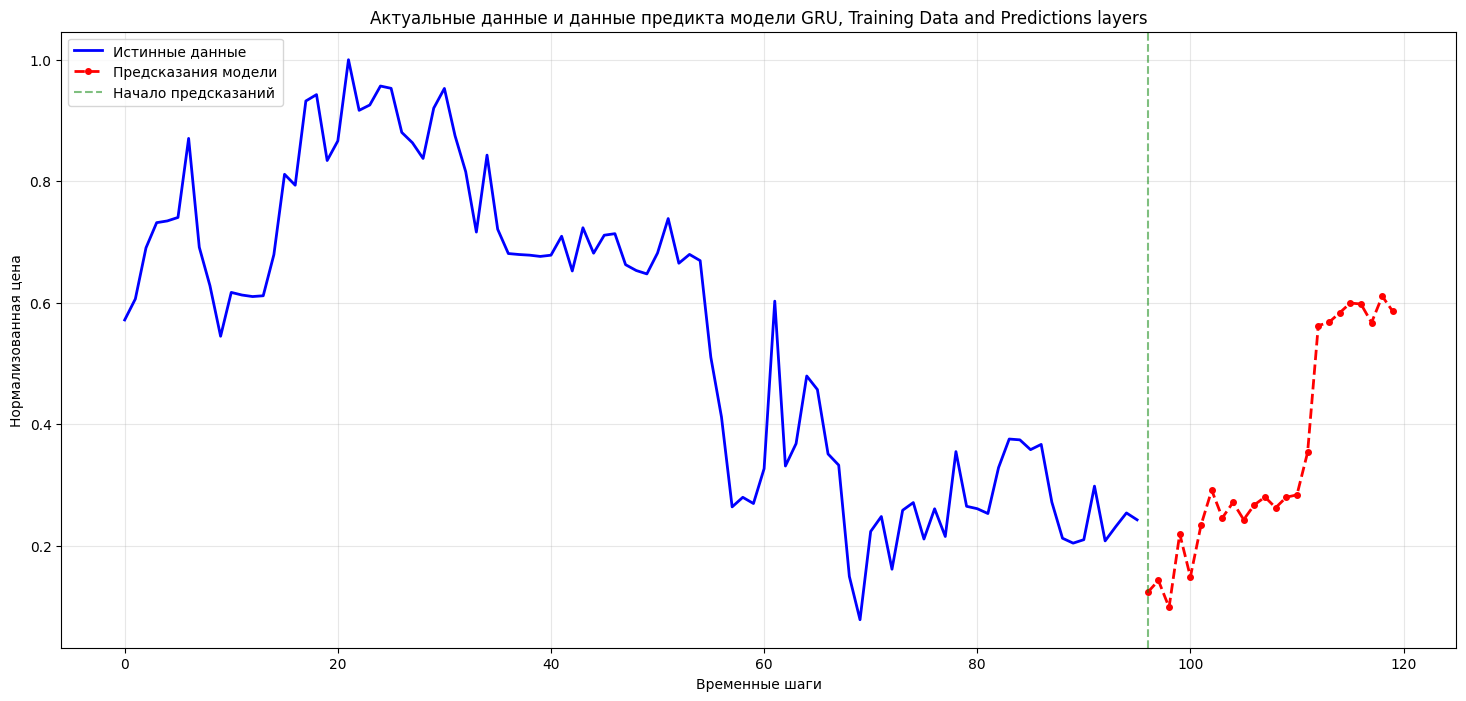

In [128]:
predict_model = convert_predict_to_df(predict_keras_GRU, x_test.index)
visual_actual_or_prediction(y_train, predict_model, 'GRU', 'Training Data and Predictions')

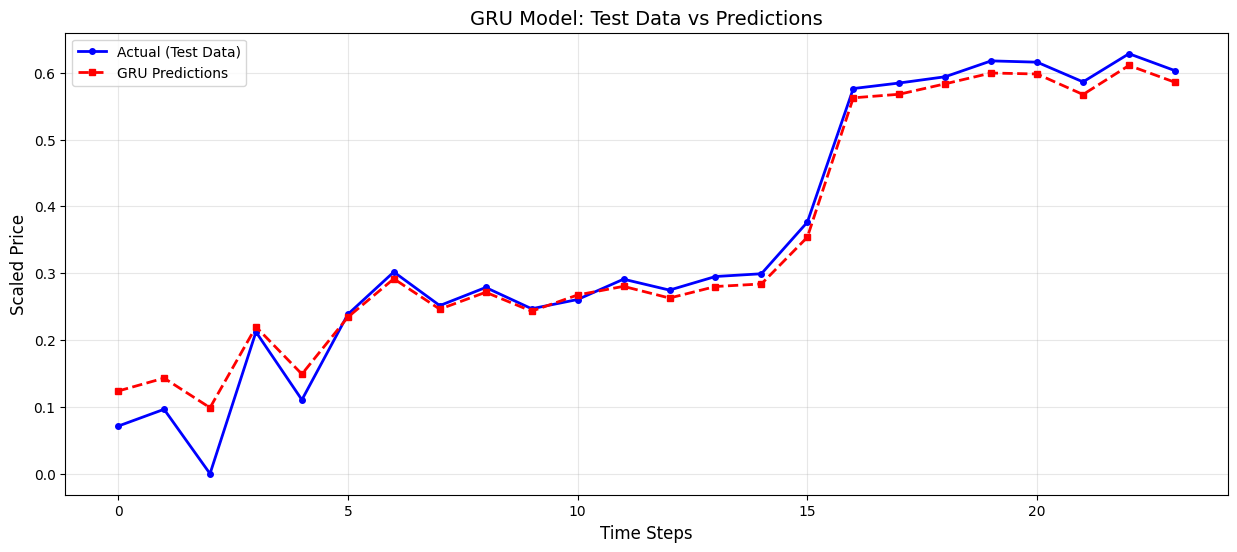

In [122]:
if 'y_test' in locals():
    plt.figure(figsize=(15, 6))
    x_axis = range(len(y_test))
    plt.plot(x_axis, y_test, 'b-', label='Actual (Test Data)', linewidth=2, marker='o', markersize=4)
    plt.plot(x_axis, predict_model, 'r--', label='GRU Predictions', linewidth=2, marker='s', markersize=4)
    plt.title('GRU Model: Test Data vs Predictions', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Scaled Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [126]:
def keras_RNN(x_tr, y_tr, x_tt):

    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode='auto',
        restore_best_weights=True,
        verbose=1
    )

    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.SimpleRNN(64),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu', kernel_regularizer='l2'),
        keras.layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    history = model.fit(x_tr, y_tr, epochs=100, batch_size=32,
                        verbose=0, callbacks=[stopping_])

    predict = model.predict(x_tt, verbose=0)

    return model, history, predict

In [127]:
model_keras_RNN, history_RNN, predict_keras_RNN = keras_RNN(x_train, y_train, x_test)

Restoring model weights from the end of the best epoch: 100.


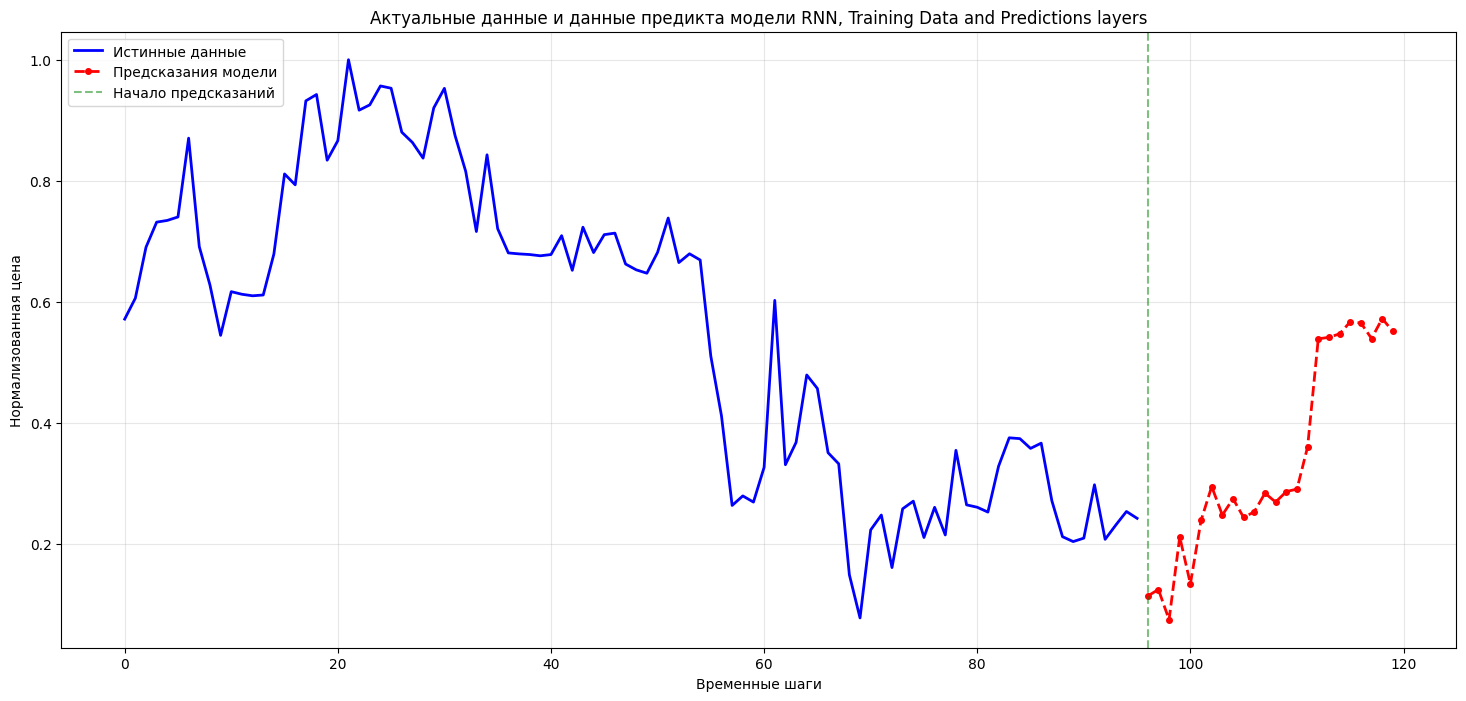

In [129]:
predict_model = convert_predict_to_df(predict_keras_RNN, x_test.index)
visual_actual_or_prediction(y_train, predict_model, 'RNN', 'Training Data and Predictions')

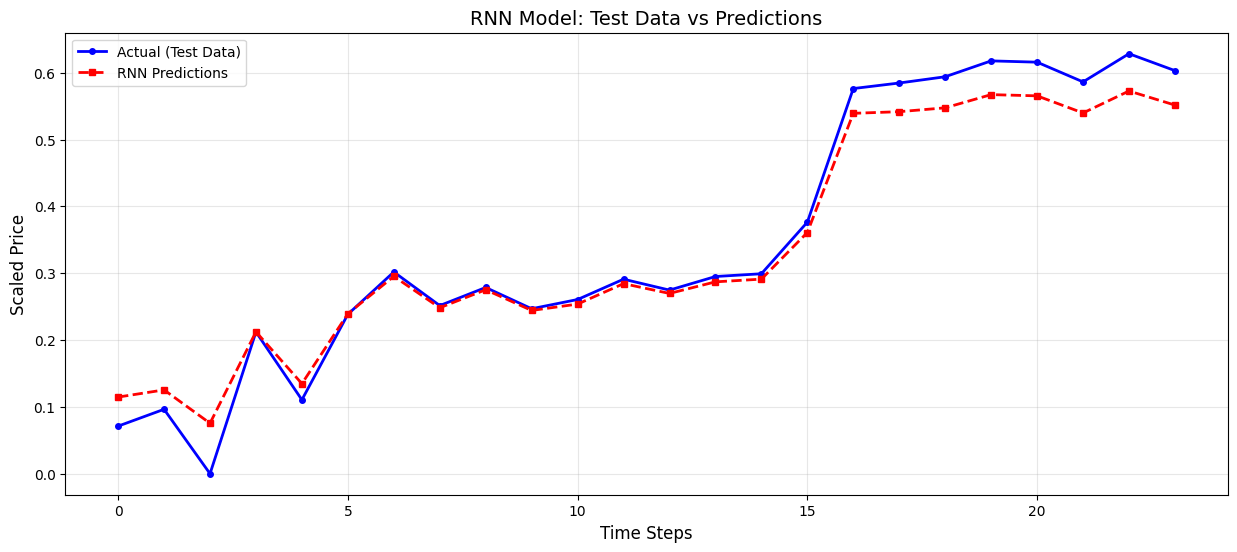

In [132]:
if 'y_test' in locals():
    plt.figure(figsize=(15, 6))
    x_axis = range(len(y_test))
    plt.plot(x_axis, y_test, 'b-', label='Actual (Test Data)', linewidth=2, marker='o', markersize=4)
    plt.plot(x_axis, predict_model, 'r--', label='RNN Predictions', linewidth=2, marker='s', markersize=4)
    plt.title('RNN Model: Test Data vs Predictions', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Scaled Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()